<a href="https://colab.research.google.com/github/freyasheth/smart-home-energy-prediction/blob/main/UCI_dataset_energy_usage_prediction_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Future energy usage prediction models for smart homes

Import libraries

In [ ]:
import os
import urllib.request
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Conv1D, LSTM, GRU, Dense, Dropout, concatenate, Flatten, Layer
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

Loading the UCI Dataset

In [ ]:
#this uses UCI dataset - household power consumption
#It has features like power,voltage,time- similar to the one used in the research paper
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip"
ZIP_PATH = "household_power_consumption.zip"
TXT_PATH = "household_power_consumption.txt"

if not os.path.exists(TXT_PATH):
    print("Downloading UCI Dataset...")
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall()
    print("Download and extraction complete.")

#load the dataset
print("Loading dataset...")
df = pd.read_csv(TXT_PATH, sep=';', parse_dates={'Datetime': ['Date', 'Time']},
                 infer_datetime_format=True, low_memory=False, na_values=['?'])

#handling missing values-forward fill : replace the missing value with its previous value
df.fillna(method='ffill', inplace=True)

#making index on date time
df.set_index('Datetime', inplace=True)

#grouping on 1 hour intervals and taking mean: as per the research paper
df = df.resample('H').mean()

# Features: Global Reactive Power, Voltage, Global Intensity
features = ['Global_reactive_power', 'Voltage', 'Global_intensity']
target = ['Global_active_power']

Download and extraction complete.
Loading dataset...


/tmp/ipykernel_631/1714823854.py:19: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(TXT_PATH, sep=';', parse_dates={'Datetime': ['Date', 'Time']},
/tmp/ipykernel_631/1714823854.py:19: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(TXT_PATH, sep=';', parse_dates={'Datetime': ['Date', 'Time']},
/tmp/ipykernel_631/1714823854.py:19: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(TXT_PATH, sep=';', parse_dates={'Datetime': ['Date', 'Time']},
/tmp/ipykernel_631/1714823854.py:23: FutureWa

Data Preprocessing

In [ ]:
#data splitting 80%-training, 20% testing
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

#normalization
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

train_X_scaled = X_scaler.fit_transform(train_df[features])
train_y_scaled = y_scaler.fit_transform(train_df[target])

test_X_scaled = X_scaler.transform(test_df[features])
test_y_scaled = y_scaler.transform(test_df[target])

#function to create sequential data to be used in the cnn-lstm model
def create_sequences(X_data, y_data, lookback):
    X, y = [], []
    for i in range(len(X_data) - lookback):
        X.append(X_data[i:(i + lookback), :])
        y.append(y_data[i + lookback, 0])
    return np.array(X), np.array(y)

#window size:24 hrs , use values of past 24 hours to predict the next value
LOOKBACK = 24

#number of features
n_features = train_X_scaled.shape[1]


#create sequential data for both train and test data
X_train, y_train = create_sequences(train_X_scaled, train_y_scaled, LOOKBACK)
X_test, y_test = create_sequences(test_X_scaled, test_y_scaled, LOOKBACK)

# **Model training**
We are training 4 different models for 4 different architectures and then evaluating their performance.





*  **Sequential CNN-LSTM :** as per the research paper:
The CNN Part learns regular, repeating habits like using a toaster every morning.The LSTM part learns unpredictable changes or unusual behaviors that don't follow a routine.
*   **Parallel CNN-LSTM:**
Instead of one after the other, this model runs the CNN and LSTM side-by-side at the same time.The CNN part looks for sudden energy spikes like turning on a high-power AC), while the LSTM part looks at long-term trends.It combines both views at the end to give a more complete picture of usage.


*   **CNN-GRU:**
This model replaces the heavy LSTMs for GRUs, which are lighter and faster. It is designed for "resource-constrained environments" like the Jetson Nano mentioned in the paper.It trains faster but still handles complex data well.It aligns with the paper's plan to move toward TinyML—making AI run on even smaller, low-power chips.
*   **Attention-LSTM:**
It adds an "Attention" layer that lets the model focus on the most important parts of the past.Instead of looking at the last 24 hours equally, it gives more weight to critical times, like peak evening hours.






In [ ]:
#sequential cnn-lstm model
#make the layers for the model : 5 CNN layers with relu activation going from 64 to 256 and back to 64, 6 LSTM layers with tanh activation 64 to 128 to 64
#cnn are used to recognise repititive consumption patterns
#lstm is used to recognize unpredicted patterns
def build_paper_baseline(seq_len, n_feat):
    """Architecture 1: The sequential CNN-LSTM from the research paper."""
    model = Sequential(name="Paper_Baseline_CNN_LSTM")
    # 5 CNN Layers
    model.add(Conv1D(64, 3, activation='relu', padding='same', input_shape=(seq_len, n_feat)))
    model.add(Conv1D(128, 3, activation='relu', padding='same'))
    model.add(Conv1D(256, 3, activation='relu', padding='same'))
    model.add(Conv1D(128, 3, activation='relu', padding='same'))
    model.add(Conv1D(64, 3, activation='relu', padding='same'))

    # 6 LSTM Layers
    model.add(LSTM(64, activation='tanh', return_sequences=True))
    model.add(LSTM(128, activation='tanh', return_sequences=True))
    model.add(LSTM(256, activation='tanh', return_sequences=True))
    model.add(LSTM(128, activation='tanh', return_sequences=True))
    model.add(LSTM(64, activation='tanh', return_sequences=True))
    model.add(LSTM(n_feat, activation='tanh', return_sequences=False))

    #dropout of 0.1 as per the research paper
    model.add(Dropout(0.1))
    model.add(Dense(1, activation='linear'))

    #adam optimizer and mse loss as per the research paper
    model.compile(optimizer='adam', loss='mse')

    #return the model
    return model

def build_parallel_cnn_lstm(seq_len, n_feat):
    """Architecture 2: Multi-Model Branching for combined temporal and local feature extraction."""
    inputs = Input(shape=(seq_len, n_feat), name="Input")

    # cnn layers for detcting sudden spikes, keeping same activation function as sequential model
    cnn = Conv1D(64, 3, activation='relu', padding='same')(inputs)
    cnn = Conv1D(128, 3, activation='relu', padding='same')(cnn)
    cnn = Flatten()(cnn)
    cnn = Dense(64, activation='relu')(cnn)

    # lstm layers for long term trends
    lstm = LSTM(128, activation='tanh', return_sequences=True)(inputs)
    lstm = LSTM(64, activation='tanh', return_sequences=False)(lstm)

    # Combine
    merged = concatenate([cnn, lstm])
    merged = Dropout(0.2)(merged)
    dense = Dense(32, activation='relu')(merged)
    outputs = Dense(1, activation='linear')(dense)

    model = Model(inputs=inputs, outputs=outputs, name="Parallel_CNN_LSTM")
    #same optimizer and loss functions
    model.compile(optimizer='adam', loss='mse')
    return model

#cnn-gru model
def build_cnn_gru(seq_len, n_feat):
    """Architecture 3: CNN-GRU. GRUs solve the vanishing gradient problem faster than LSTMs."""
    model = Sequential(name="CNN_GRU")
    model.add(Conv1D(64, 3, activation='relu', padding='same', input_shape=(seq_len, n_feat)))
    model.add(Conv1D(128, 3, activation='relu', padding='same'))

    #using gru instead of lstm
    model.add(GRU(128, activation='tanh', return_sequences=True))
    model.add(GRU(64, activation='tanh', return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='linear'))

    #same optimizer and loss functions
    model.compile(optimizer='adam', loss='mse')
    return model


#attention-lstm model
def build_attention_lstm(seq_len, n_feat):
    """Architecture 4: LSTM with Self-Attention. Highlights which parts of the time-series matter most."""
    inputs = Input(shape=(seq_len, n_feat))

    lstm_out = LSTM(128, return_sequences=True)(inputs)

    # attention layer
    attention = Dense(1, activation='tanh')(lstm_out)
    attention = Flatten()(attention)
    attention = tf.keras.layers.Activation('softmax')(attention)
    attention = tf.keras.layers.RepeatVector(128)(attention)
    attention = tf.keras.layers.Permute([2, 1])(attention)

    sent_representation = tf.keras.layers.Multiply()([lstm_out, attention])
    sent_representation = tf.keras.layers.Lambda(lambda xin: tf.keras.backend.sum(xin, axis=1))(sent_representation)

    dense1 = Dense(64, activation='relu')(sent_representation)
    outputs = Dense(1, activation='linear')(dense1)

    model = Model(inputs=inputs, outputs=outputs, name="Attention_LSTM")
    model.compile(optimizer='adam', loss='mse')
    return model

Model evaluation

In [ ]:
import time

# Define all the models
architectures = [
    build_paper_baseline(LOOKBACK, n_features),
    build_parallel_cnn_lstm(LOOKBACK, n_features),
    build_cnn_gru(LOOKBACK, n_features),
    build_attention_lstm(LOOKBACK, n_features)
]

# List to store the evaluation metrics
comparison_results = []

print("\nStarting Multi-Architecture Training & Evaluation...")

for model in architectures:
    print(f"\n{'='*50}")
    print(f"Training Architecture: {model.name}")
    print(f"{'='*50}")


    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0),
        ModelCheckpoint(f"best_{model.name}.keras", save_best_only=True, monitor="val_loss", verbose=0)
    ]

    start_time = time.time()

    # Train the model
    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_data=(X_test, y_test),
        callbacks=callbacks,
        verbose=0
    )

    training_time = time.time() - start_time

    # Evaluate
    predictions_scaled = model.predict(X_test, verbose=0)
    predictions = y_scaler.inverse_transform(predictions_scaled)
    y_test_actual = y_scaler.inverse_transform(y_test.reshape(-1, 1))

    # Calculate Metrics
    mse = mean_squared_error(y_test_actual, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_actual, predictions)
    mape = mean_absolute_percentage_error(y_test_actual, predictions) * 100
    r2 = r2_score(y_test_actual, predictions)

    # Store results
    comparison_results.append({
        "Architecture": model.name,
        "MSE": round(mse, 4),
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4),
        "MAPE (%)": round(mape, 2),
        "R-Squared": round(r2, 4),
        "Train Time (s)": round(training_time, 1)
    })

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Starting Multi-Architecture Training & Evaluation...

Training Architecture: Paper_Baseline_CNN_LSTM

Training Architecture: Parallel_CNN_LSTM

Training Architecture: CNN_GRU

Training Architecture: Attention_LSTM


Using SHAP (SHapley Additive exPlanations) not only to predict energy use but also to understand the why behind the predictions.


Generating SHAP feature importance...


  0%|          | 0/20 [00:00<?, ?it/s]

SHAP values calculated successfully.


/tmp/ipykernel_631/2668609722.py:43: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


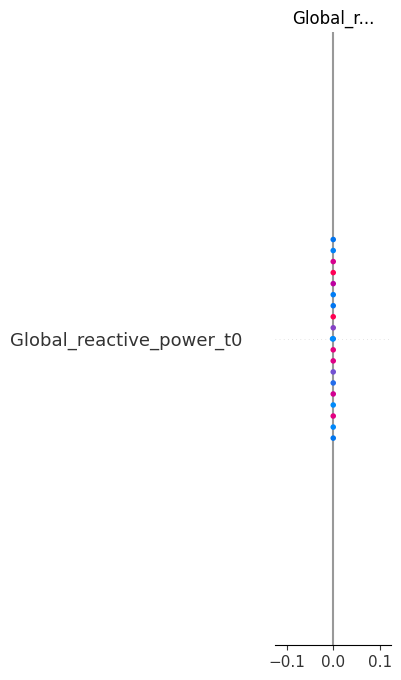

In [ ]:
print("\nGenerating SHAP feature importance...")

import shap
import numpy as np

# Flatten input for model
n_timesteps = X_train.shape[1]
n_features = X_train.shape[2]

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Small background set for speed
bg_idx = np.random.choice(X_train_flat.shape[0], min(50, X_train_flat.shape[0]), replace=False)
background_flat = X_train_flat[bg_idx]

# Small explanation batch for speed
X_explain_flat = X_test_flat[:20]

# Prediction wrapper
def predict_fn(x_flat):
    x_3d = x_flat.reshape(-1, n_timesteps, n_features)
    preds = model.predict(x_3d, verbose=0)
    return preds.reshape(-1, 1)

explainer = shap.KernelExplainer(predict_fn, background_flat)
shap_values = explainer.shap_values(X_explain_flat)

print("SHAP values calculated successfully.")

# Handle output shape
if isinstance(shap_values, list):
    shap_values_plot = shap_values[0]
else:
    shap_values_plot = shap_values

flat_feature_names = [
    f"{features[f]}_t{t}"
    for t in range(n_timesteps)
    for f in range(n_features)
]

shap.summary_plot(
    shap_values_plot,
    X_explain_flat,
    feature_names=flat_feature_names
)

Save the models

In [ ]:
import os
os.makedirs("saved_models", exist_ok=True)

for model in architectures:
    model.save(f"saved_models/{model.name}.keras")
    print(f"Saved: saved_models/{model.name}.keras")

Saved: saved_models/Paper_Baseline_CNN_LSTM.keras
Saved: saved_models/Parallel_CNN_LSTM.keras
Saved: saved_models/CNN_GRU.keras
Saved: saved_models/Attention_LSTM.keras
